Plot skewness and Kurtosis of samples of inter-arrival and service distribution based on their moments.

In [16]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from Sampling.Save_Combine_Read_for_CSV_files import Load_Samples_from_file
from Training.Class_training import NN_for_Queue


In [17]:
##### Parameters
n_max = 10           # The highest order of moments
Lmax = 500           # The maximum queue length
m_max = 15           # The maximum order of PH-representation (alpha, T)
input_dim = 2*n_max  # DNN input dimension: arrival n_max + service n_max


In [18]:
def normalize_moments_to_mean_one(moms):
    """
    moms: shape (N, >=4), raw moments m1, m2, m3, m4
    returns: normalized moments with mean = 1
    """
    m1 = moms[:, 0]
    moms_norm = moms.copy()

    # m_k(X / m1) = m_k(X) / m1^k
    for k in range(moms.shape[1]):
        moms_norm[:, k] = moms[:, k] / (m1 ** (k + 1)) # normalize by dividing by (m1 ** (k + 1))

    return moms_norm


In [19]:
def skew_kurt_from_raw_moments(moms):
    """
    moms: shape (N, >=4), raw moments with mean already normalized to 1
    """
    m1, m2, m3, m4 = moms[:,0], moms[:,1], moms[:,2], moms[:,3]
    
    var = m2 - m1**2
    std = np.sqrt(var)

    mu3 = m3 - 3*m2*m1 + 2*m1**3 # third central moment
    mu4 = m4 - 4*m3*m1 + 6*m2*m1**2 - 3*m1**4 # fourth central moment

    skew = mu3 / std**3 # Skewness
    kurt = mu4 / std**4 # Kurtosis

    return skew, kurt

In [20]:
def summary_table(x, name='skewness'):
    summary = {
        'Count': len(x),
        'Mean': np.mean(x),
        'Std': np.std(x, ddof=1),
        'Min': np.min(x),
        '10%': np.quantile(x, 0.10),
        '25%': np.quantile(x, 0.25),
        'Median': np.quantile(x, 0.50),
        '75%': np.quantile(x, 0.75),
        '90%': np.quantile(x, 0.90),
        'Max': np.max(x)
    }
    return pd.DataFrame(summary, index=[name])


In [21]:
# funct skew and kurt given K and queue_type
def df_skew_kurt(queue_type):

    df_all = None
    for K in [1,2,3]:
        # load samples
        DNN_net = NN_for_Queue(
            queue_type=queue_type, n_max=n_max, Lmax=Lmax, m_max=m_max, input_dim=input_dim, num_classes=Lmax
        )

        df_all_K = DNN_net.Load_and_Merge_All_Samples_for_K(K) 

        # sample shape
        print("Total samples for K=", K, ":", df_all_K.shape[0])

        # Break samples into Moments, stationary distribution, and rho blocks
        Moments_all, Stationary_all, rho_all = Load_Samples_from_file(n_max, Lmax, df_all_K)

        # load extra data for discrete case
        if queue_type == 'discrete':
            # read data with coxian and erlang
            df_dis_coxian = pd.read_csv(f'Output/samples/discrete/K{K}_erlang_coxian/sample_K{K}_discrete_erlang_coxian.csv')
            Moments_all_2 = df_dis_coxian.iloc[:,:20].values
            Moments_all_2 = Moments_all_2.astype(float)
            #print(Moments_all_2.shape)

        # convert to float
        Moments_all = Moments_all.astype(float)
        Stationary_all = Stationary_all.astype(float)

        if queue_type == 'discrete':
            #print( Moments_all.shape)
            Moments_all = np.vstack((Moments_all, Moments_all_2))

        # vstack
        if df_all is None:
            df_all = Moments_all
        else:
            df_all = np.vstack((df_all, Moments_all))

    print('df_all shape', df_all.shape)

    return df_all

In [29]:
# loop over queue_type for all samples
queue_type = 'discrete'
print(f"Processing queue_type={queue_type}")
df_all = df_skew_kurt(queue_type)


Processing queue_type=discrete
The queue type is discrete
load samples: queue type is discrete
Total samples for K= 1 : 482270
The queue type is discrete
load samples: queue type is discrete
Total samples for K= 2 : 89216
The queue type is discrete
load samples: queue type is discrete
Total samples for K= 3 : 42126
df_all shape (678612, 20)


C:\Users\he201\AppData\Local\Temp\ipykernel_7800\482704810.py:20: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\he201\anaconda3\envs\GIGKQueue\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


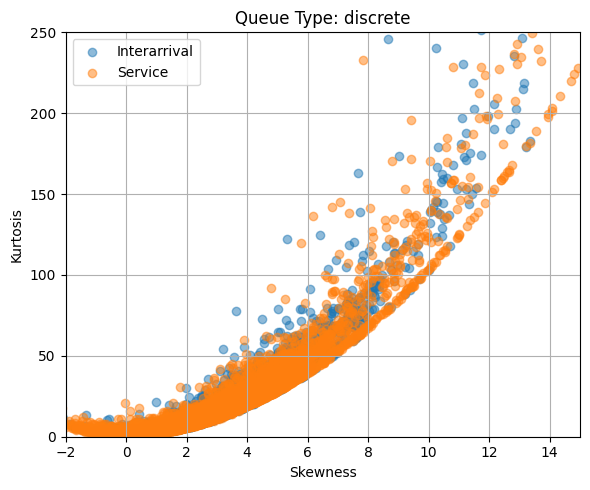

In [30]:
Moments_all_real = np.exp(df_all) -1 # transfer back to moments
Moments_arrival = Moments_all_real[:, :n_max] # obtain arrival monents
Moments_service = Moments_all_real[:, n_max:] # obtain service moments
# 1. mean normalization
mom_arr_n = normalize_moments_to_mean_one(Moments_arrival)
mom_ser_n = normalize_moments_to_mean_one(Moments_service)
# 2. skewness & kurtosis
skew_a, kurt_a = skew_kurt_from_raw_moments(mom_arr_n)
skew_s, kurt_s = skew_kurt_from_raw_moments(mom_ser_n)  
plt.figure(figsize=(6,5))
plt.scatter(skew_a, kurt_a, alpha=0.5, label='Interarrival')
plt.scatter(skew_s, kurt_s, alpha=0.5, label='Service')
plt.xlabel('Skewness')
plt.ylabel('Kurtosis')
plt.xlim(-2,15)
plt.ylim(0,250)
plt.title(f'Queue Type: {queue_type}')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


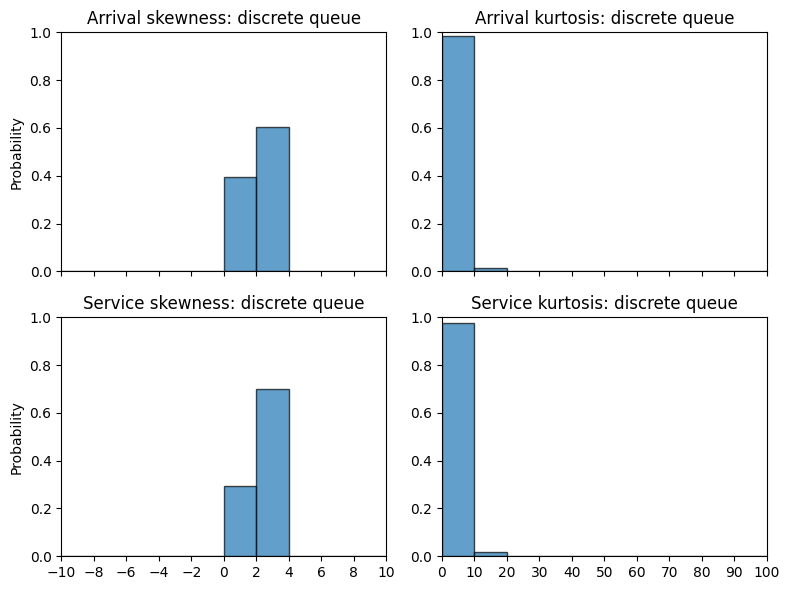

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(8,6), sharex='col')

# Bin settings
bins_skew = np.arange(-10, 11, 2)     # include 10
bins_kurt = np.arange(0, 101, 10)   # include 100

# Arrival skewness
counts, bin_edges = np.histogram(skew_a, bins=bins_skew)
probs = counts / counts.sum()

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]

axes[0,0].bar(bin_centers, probs, width=bin_width, edgecolor='black', alpha=0.7)
axes[0,0].set_title('Arrival skewness: discrete queue')
axes[0,0].set_xlim(0, 10)
axes[0,0].set_ylim(0, 1)
axes[0,0].set_ylabel('Probability')
axes[0,0].set_xticks(bin_edges)

# Arrival kurtosis
counts, bin_edges = np.histogram(kurt_a, bins=bins_kurt)
probs = counts / counts.sum()

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]

axes[0,1].bar(bin_centers, probs, width=bin_width, edgecolor='black', alpha=0.7)
axes[0,1].set_title('Arrival kurtosis: discrete queue')
axes[0,1].set_xlim(0, 100)
axes[0,1].set_ylim(0, 1)
axes[0,1].set_xticks(bin_edges)

# Service skewness
counts, bin_edges = np.histogram(skew_s, bins=bins_skew)
probs = counts / counts.sum()

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]

axes[1,0].bar(bin_centers, probs, width=bin_width, edgecolor='black', alpha=0.7)
axes[1,0].set_title('Service skewness: discrete queue')
axes[1,0].set_xlim(-10, 10)
axes[1,0].set_ylim(0, 1)
axes[1,0].set_ylabel('Probability')
axes[1,0].set_xticks(bin_edges)

# Service kurtosis
counts, bin_edges = np.histogram(kurt_s, bins=bins_kurt)
probs = counts / counts.sum()

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]

axes[1,1].bar(bin_centers, probs, width=bin_width, edgecolor='black', alpha=0.7)
axes[1,1].set_title('Service kurtosis: discrete queue')
axes[1,1].set_xlim(0, 100)
axes[1,1].set_ylim(0, 1)
axes[1,1].set_xticks(bin_edges)

plt.tight_layout()
plt.show()

In [25]:
# loop over queue_type for all samples
queue_type = 'continuous'
print(f"Processing queue_type={queue_type}")
df_all_c = df_skew_kurt(queue_type)


Processing queue_type=continuous
The queue type is continuous
load samples: queue type is continuous
Total samples for K= 1 : 530025
The queue type is continuous
load samples: queue type is continuous
Total samples for K= 2 : 101025
The queue type is continuous
load samples: queue type is continuous
Total samples for K= 3 : 68219
df_all shape (699269, 20)


C:\Users\he201\AppData\Local\Temp\ipykernel_7800\3023395600.py:20: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\he201\anaconda3\envs\GIGKQueue\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


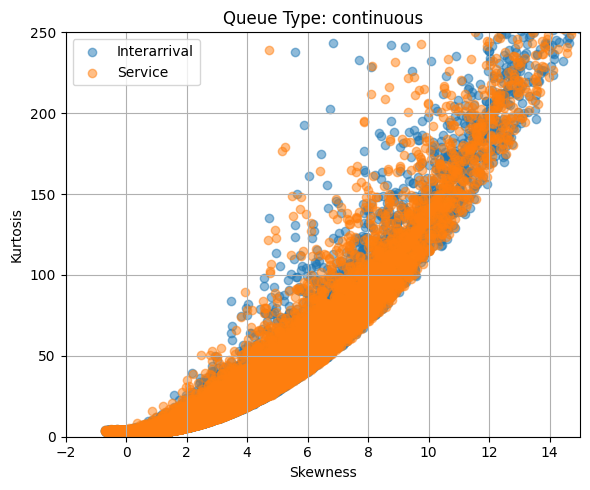

In [26]:
Moments_all_real = np.exp(df_all_c) -1 # transfer back to moments
Moments_arrival = Moments_all_real[:, :n_max] # obtain arrival monents
Moments_service = Moments_all_real[:, n_max:] # obtain service moments
# 1. mean normalization
mom_arr_n = normalize_moments_to_mean_one(Moments_arrival)
mom_ser_n = normalize_moments_to_mean_one(Moments_service)
# 2. skewness & kurtosis
skew_a, kurt_a = skew_kurt_from_raw_moments(mom_arr_n)
skew_s, kurt_s = skew_kurt_from_raw_moments(mom_ser_n)  
plt.figure(figsize=(6,5))
plt.scatter(skew_a, kurt_a, alpha=0.5, label='Interarrival')
plt.scatter(skew_s, kurt_s, alpha=0.5, label='Service')
plt.xlabel('Skewness')
plt.ylabel('Kurtosis')
plt.xlim(-2,15)
plt.ylim(0,250)
plt.title(f'Queue Type: {queue_type}')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


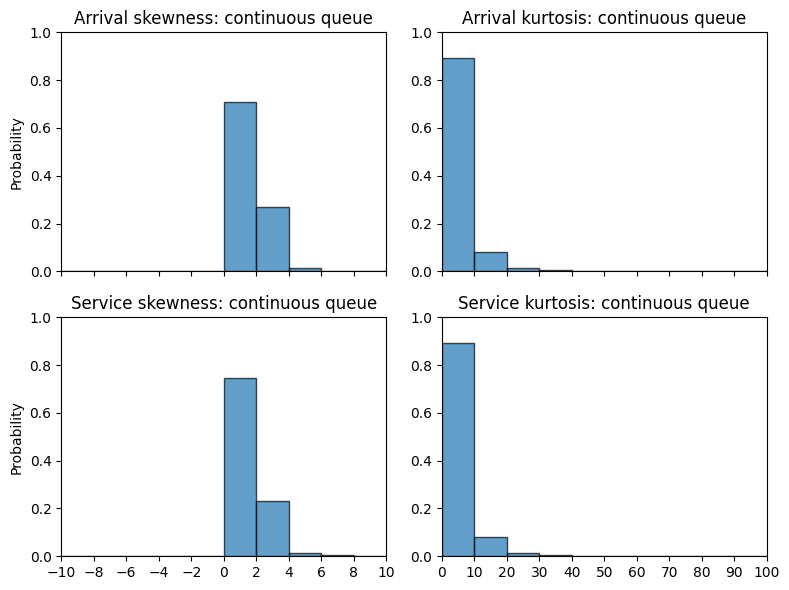

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(8,6), sharex='col')

# Bin settings
bins_skew = np.arange(-10, 11, 2)     # include 10
bins_kurt = np.arange(0, 101, 10)   # include 100

# Arrival skewness
counts, bin_edges = np.histogram(skew_a, bins=bins_skew)
probs = counts / counts.sum()

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]

axes[0,0].bar(bin_centers, probs, width=bin_width, edgecolor='black', alpha=0.7)
axes[0,0].set_title('Arrival skewness: continuous queue')
axes[0,0].set_xlim(0, 10)
axes[0,0].set_ylim(0, 1)
axes[0,0].set_ylabel('Probability')
axes[0,0].set_xticks(bin_edges)

# Arrival kurtosis
counts, bin_edges = np.histogram(kurt_a, bins=bins_kurt)
probs = counts / counts.sum()

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]

axes[0,1].bar(bin_centers, probs, width=bin_width, edgecolor='black', alpha=0.7)
axes[0,1].set_title('Arrival kurtosis: continuous queue')
axes[0,1].set_xlim(0, 100)
axes[0,1].set_ylim(0, 1)
axes[0,1].set_xticks(bin_edges)

# Service skewness
counts, bin_edges = np.histogram(skew_s, bins=bins_skew)
probs = counts / counts.sum()

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]

axes[1,0].bar(bin_centers, probs, width=bin_width, edgecolor='black', alpha=0.7)
axes[1,0].set_title('Service skewness: continuous queue')
axes[1,0].set_xlim(-10, 10)
axes[1,0].set_ylim(0, 1)
axes[1,0].set_ylabel('Probability')
axes[1,0].set_xticks(bin_edges)

# Service kurtosis
counts, bin_edges = np.histogram(kurt_s, bins=bins_kurt)
probs = counts / counts.sum()

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]

axes[1,1].bar(bin_centers, probs, width=bin_width, edgecolor='black', alpha=0.7)
axes[1,1].set_title('Service kurtosis: continuous queue')
axes[1,1].set_xlim(0, 100)
axes[1,1].set_ylim(0, 1)
axes[1,1].set_xticks(bin_edges)

plt.tight_layout()
plt.show()